In [1]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=["sepal_length", "sepal_width", "petal_length", "petal_width"])

df.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [2]:
print(df.isnull().sum())

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
dtype: int64


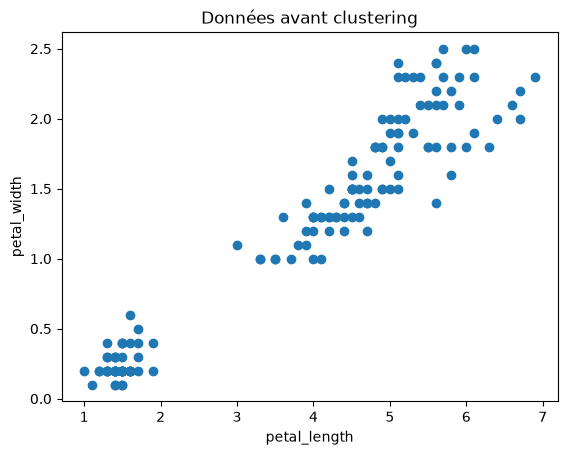

In [3]:
import matplotlib.pyplot as plt

plt.scatter(df["petal_length"], df["petal_width"])
plt.xlabel("petal_length")
plt.ylabel("petal_width")
plt.title("Données avant clustering")
plt.show()

In [4]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

print("Centres :")
print(kmeans.cluster_centers_)
print("Étiquettes :", labels)

Centres :
[[-0.05021989 -0.88337647  0.34773781  0.2815273 ]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 1.13597027  0.08842168  0.99615451  1.01752612]]
Étiquettes : [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 0 0 0 2 0 0 0 0 0 0 0 0 2 0 0 0 0 2 0 0 0
 0 2 2 2 0 0 0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 2 2 2 2 2 2 0 0 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


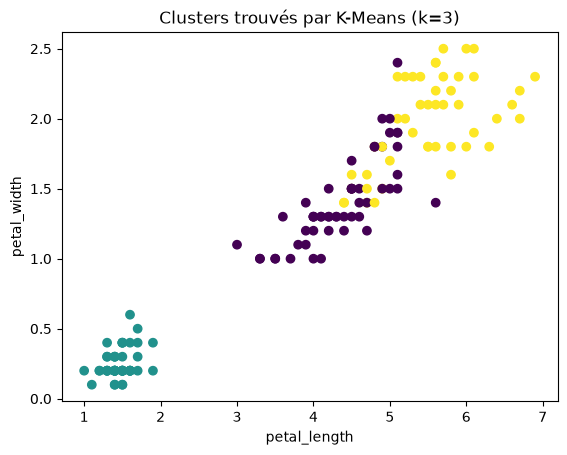

Silhouette score : 0.46


In [5]:
plt.scatter(df["petal_length"], df["petal_width"], c=labels)
plt.xlabel("petal_length")
plt.ylabel("petal_width")
plt.title("Clusters trouvés par K-Means (k=3)")
plt.show()

from sklearn.metrics import silhouette_score
print("Silhouette score :", round(silhouette_score(X_scaled, labels), 2))

In [6]:
for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    l = km.fit_predict(X_scaled)
    print("k =", k, "-> silhouette :", round(silhouette_score(X_scaled, l), 2))

k = 2 -> silhouette : 0.58
k = 3 -> silhouette : 0.46
k = 4 -> silhouette : 0.39
k = 5 -> silhouette : 0.35


Sans normalisation : [1 1 1 1 1 1 1 1 1 1]
Avec normalisation : [1 1 1 1 1 1 1 1 1 1]


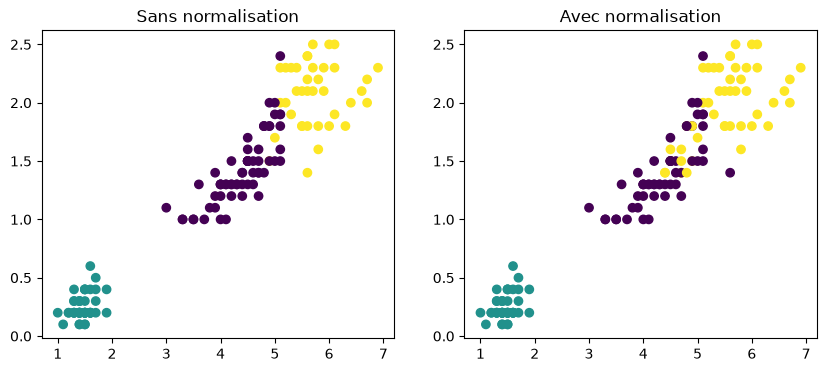

In [7]:
km_brut = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_brut = km_brut.fit_predict(df)

print("Sans normalisation :", labels_brut[:10])
print("Avec normalisation :", labels[:10])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(df["petal_length"], df["petal_width"], c=labels_brut)
axes[0].set_title("Sans normalisation")
axes[1].scatter(df["petal_length"], df["petal_width"], c=labels)
axes[1].set_title("Avec normalisation")
plt.show()